<a href="https://colab.research.google.com/github/tbkashin/Machine-Learning/blob/Homework/Homework_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Question 1


In [4]:
import numpy as np

# Define feature vectors
x1 = np.array([2, 3, 4, 8, 9])
x2 = np.array([2, -3, -4, 89])

# a)
print(f"a)")
#Number of features in x1 and x2
num_features_x1 = len(x1)
num_features_x2 = len(x2)

print(f"Number of features in x1: {num_features_x1}")
print(f"Number of features in x2: {num_features_x2}")

# b)
print(f"\nb)")

# L1 norm
l1_x1 = np.linalg.norm(x1, ord=1)
l1_x2 = np.linalg.norm(x2, ord=1)

# L2 norm
l2_x1 = np.linalg.norm(x1, ord=2)
l2_x2 = np.linalg.norm(x2, ord=2)

# L_inf norm
linf_x1 = np.linalg.norm(x1, ord=np.inf)
linf_x2 = np.linalg.norm(x2, ord=np.inf)

print("Norms for x1:")
print(f"  L1 norm:       {l1_x1}")
print(f"  L2 norm:       {l2_x1:.4f}")
print(f"  L_inf norm:    {linf_x1}")

print("Norms for x2:")
print(f"  L1 norm:       {l1_x2}")
print(f"  L2 norm:       {l2_x2:.4f}")
print(f"  L_inf norm:    {linf_x2}")

a)
Number of features in x1: 5
Number of features in x2: 4

b)
Norms for x1:
  L1 norm:       26.0
  L2 norm:       13.1909
  L_inf norm:    9.0
Norms for x2:
  L1 norm:       98.0
  L2 norm:       89.1628
  L_inf norm:    89.0


# Question 2


In [5]:
# Dimensions
input_height, input_width = 1024, 1024
output_height, output_width = 64, 64

# RGB Image parameters
channels = 3

# a) Length of input vector x
print("a)")
len_x = input_height * input_width * channels
print(f"Length of the input vector x: {len_x:,}")

# b) Length of output vector y
print("\nb)")
len_y = output_height * output_width * channels
print(f"Length of the output vector y: {len_y:,}")

# c) Number of elements in matrix W and vector b
print("\nc)")
elements_W = len_x * len_y
elements_b = len_y

print(f"Number of elements in matrix W: {elements_W:,}")
print(f"Number of elements in vector b: {elements_b:,}")

a)
Length of the input vector x: 3,145,728

b)
Length of the output vector y: 12,288

c)
Number of elements in matrix W: 38,654,705,664
Number of elements in vector b: 12,288


# Question 3

In [16]:
import numpy as np

# Define matrix W
W = np.array([[1, -1],[2,  0]])

# 1-norm
norm_1 = np.linalg.norm(W, ord=1)

# 2-norm
norm_2 = np.linalg.norm(W, ord=2)

# Infinity-norm
norm_inf = np.linalg.norm(W, ord=np.inf)

# Frobenius norm
norm_fro = np.linalg.norm(W, ord='fro')

print(f"1-norm:          {norm_1:.4f}")
print(f"2-norm:          {norm_2:.4f}")
print(f"Infinity-norm:   {norm_inf:.4f}")
print(f"Frobenius norm:  {norm_fro:.4f}")

1-norm:          3.0000
2-norm:          2.2882
Infinity-norm:   2.0000
Frobenius norm:  2.4495


# Question 4

In [24]:
from sklearn import datasets

#Load Data Base
iris = datasets.load_iris()

# Select 3 features: sepal length, sepal width, and petal length
X = iris.data[:, :3]
y = iris.target

# Split Data
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.40,
    train_size=0.60,
    random_state=123,
    shuffle=True,
    stratify=y
)

# Train Model
from sklearn import svm
clf = svm.SVC()
clf.fit(X_train, y_train)

# Compare Model Prediction and Actual Species
print("Model Prediction:")
preds = clf.predict(X_test)
print(preds)
print("\nActual Iris Species:")
print(y_test)

# Model Accuracy
from sklearn.metrics import accuracy_score
acc = accuracy_score(y_test,clf.predict(X_test) )
print(f"\nAccuracy Score: {acc:.4f}")

Model Prediction
[1 1 1 1 0 2 2 0 0 2 0 2 2 1 2 0 1 2 0 2 2 0 2 0 0 2 1 0 0 0 0 0 1 2 0 1 1
 2 0 1 0 2 2 2 0 2 2 2 0 0 1 1 2 1 2 1 1 2 1 1]

Actual Iris Species
[1 1 1 1 0 1 2 0 0 2 0 2 2 1 2 0 1 2 0 2 2 0 1 0 0 2 1 0 0 0 0 0 1 2 0 1 1
 2 0 1 0 2 2 2 0 2 2 1 0 0 1 1 2 1 2 1 1 2 1 2]

Accuracy Score: 0.9333


# Question 5

In [31]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras import optimizers

# Generate training data (input X): integers 1 to 100
X = np.arange(1, 101, dtype=np.float32).reshape(-1, 1)

# Target y: 7th root of X (X ** (1/7))
y = (X ** (1.0 / 7.0)).astype(np.float32)

# Define Keras NN model
model = Sequential()
model.add(Dense(16, input_dim=1, activation='relu'))
model.add(Dense(16, activation='relu'))
model.add(Dense(16, activation='relu'))
model.add(Dense(1))

# Compile model
opt = optimizers.Adam(learning_rate=0.005)
mse = tf.keras.losses.MeanSquaredError()
model.compile(loss=mse, optimizer=opt)

# Train model
model.fit(X, y, epochs=3000, batch_size=10, verbose=0)
model.summary()

# Display sample predictions
sample_indices = [0, 6, 15, 31, 49, 63, 79, 99]  # e.g., integers 1, 7, 16, 32, 50, 64, 80, 100
sample_X = X[sample_indices]
sample_y = y[sample_indices]
predictions = model.predict(sample_X)

print("\nSample Comparisons:")
for i in range(len(sample_indices)):
    print(f"[{sample_X[i][0]:5.1f}] => Predicted: {predictions[i][0]:.3f} | Expected: {sample_y[i][0]:.3f}")

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 16)             │            32 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,781 (6.96 KB)

 Trainable params: 593 (2.32 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,188 (4.64 KB)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step

Sample Comparisons:
[  1.0] => Predicted: 1.014 | Expected: 1.000
[  7.0] => Predicted: 1.322 | Expected: 1.320
[ 16.0] => Predicted: 1.476 | Expected: 1.486
[ 32.0] => Predicted: 1.643 | Expected: 1.641
[ 50.0] => Predicted: 1.749 | Expected: 1.749
[ 64.0] => Predicted: 1.813 | Expected: 1.811
[ 80.0] => Predicted: 1.866 | Expected: 1.870
[100.0] => Predicted: 1.933 | Expected: 1.931


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


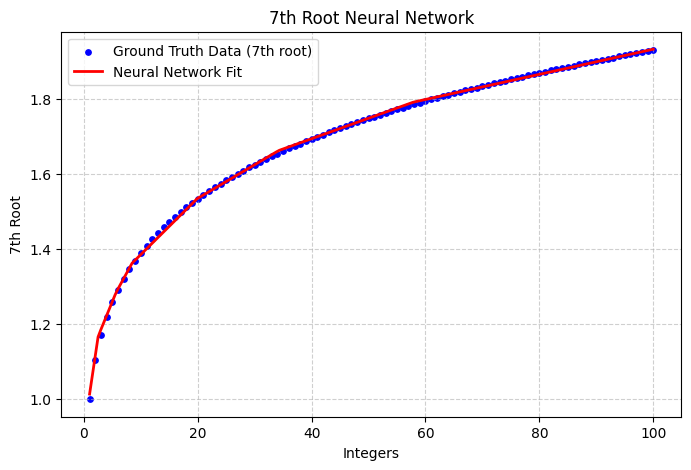

In [32]:
import matplotlib.pyplot as plt

# Generate evaluation grid
number_grid = np.linspace(1, 100, 200).reshape(-1, 1)
pred_grid = model.predict(number_grid)

# Plot actual data points vs neural network predictions
plt.figure(figsize=(8, 5))
plt.scatter(X, y, label='7th Root Data', color='blue', s=15)
plt.plot(number_grid, pred_grid, label='Neural Network ', color='red', linewidth=2)
plt.xlabel('Integers')
plt.ylabel('7th Root')
plt.title('7th Root Neural Network')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# Question 6


In [2]:
import numpy as np
import tensorflow as tf
from sklearn import datasets
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras import optimizers
from sklearn.model_selection import train_test_split

# Load Iris dataset
iris = datasets.load_iris()

# Data Setup:
# Column 0: sepal length (input X)
# Column 2: petal length (output y)
X = np.array(iris.data[:, 0], dtype=np.float32).reshape(-1, 1)
y = np.array(iris.data[:, 2], dtype=np.float32).reshape(-1, 1)

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

# Define neural network
model = Sequential()
model.add(Dense(16, input_dim=1, activation='relu'))
model.add(Dense(16, activation='relu'))
model.add(Dense(16, activation='relu'))
model.add(Dense(1))

# Compile model
opt = optimizers.Adam(learning_rate=0.01)
mse = tf.keras.losses.MeanSquaredError()
model.compile(loss=mse, optimizer=opt)

# Train model
history = model.fit(
    X_train, y_train,
    epochs=1000,
    batch_size=16,
    verbose=0,
    validation_data=(X_test, y_test)
)

Test Mean Squared Error (MSE): 0.5339
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step


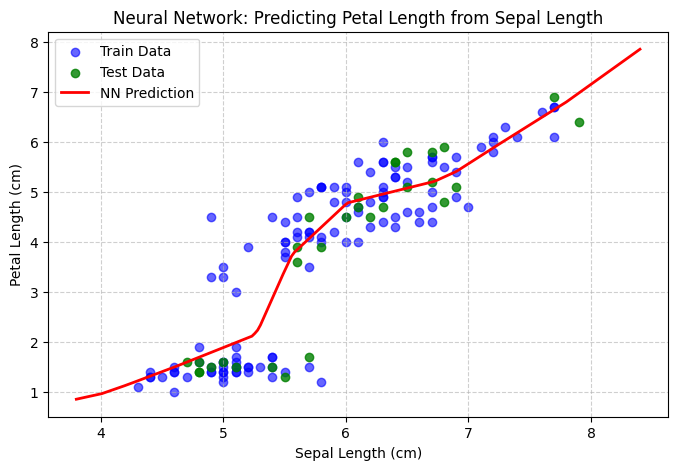

In [3]:
import matplotlib.pyplot as plt

# Evaluate test performance
test_mse = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Mean Squared Error (MSE): {test_mse:.4f}")

# Plot predictions vs actual data
X_grid = np.linspace(X.min() - 0.5, X.max() + 0.5, 200).reshape(-1, 1)
y_grid_pred = model.predict(X_grid)

plt.figure(figsize=(8, 5))
plt.scatter(X_train, y_train, color='blue', alpha=0.6, label='Train Data')
plt.scatter(X_test, y_test, color='green', alpha=0.8, label='Test Data')
plt.plot(X_grid, y_grid_pred, color='red', linewidth=2, label='NN Prediction')
plt.xlabel('Sepal Length (cm)')
plt.ylabel('Petal Length (cm)')
plt.title('Neural Network: Predicting Petal Length from Sepal Length')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()